In [8]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt


model = YOLO('../YOLOv11s-Carmaker.pt')

data = results = model('../data/image.webp')

img = cv2.imread('../data/image.webp')
dh, dw, _ = img.shape
       
colors = {
    1: (255, 165, 0),   
    3: (135, 206, 235),   
    2: (0, 0, 255)    
}

data = results[0]

data.boxes


image 1/1 /home/meel/Git/perception_module/src/../data/image.webp: 384x640 3 Blues, 2 Small Oranges, 3 Yellows, 4.2ms
Speed: 0.7ms preprocess, 4.2ms inference, 0.4ms postprocess per image at shape (1, 3, 384, 640)


ultralytics.engine.results.Boxes object with attributes:

cls: tensor([3., 3., 3., 2., 1., 2., 1., 1.], device='cuda:0')
conf: tensor([0.9330, 0.9264, 0.9237, 0.8563, 0.8056, 0.7494, 0.7337, 0.5654], device='cuda:0')
data: tensor([[3.1252e+02, 4.8504e+02, 3.6724e+02, 5.6984e+02, 9.3303e-01, 3.0000e+00],
        [4.7364e+02, 4.7941e+02, 5.2260e+02, 5.5367e+02, 9.2637e-01, 3.0000e+00],
        [6.5959e+02, 4.9735e+02, 7.2380e+02, 5.9833e+02, 9.2371e-01, 3.0000e+00],
        [5.3241e+02, 4.8098e+02, 5.8225e+02, 5.5442e+02, 8.5630e-01, 2.0000e+00],
        [4.0551e+02, 4.7747e+02, 4.5744e+02, 5.4518e+02, 8.0556e-01, 1.0000e+00],
        [5.8082e+02, 4.8665e+02, 6.3771e+02, 5.7098e+02, 7.4936e-01, 2.0000e+00],
        [2.3368e+02, 4.9688e+02, 3.0189e+02, 5.8261e+02, 7.3372e-01, 1.0000e+00],
        [7.3990e+02, 5.1137e+02, 8.4246e+02, 6.2344e+02, 5.6545e-01, 1.0000e+00]], device='cuda:0')
id: None
is_track: False
orig_shape: (720, 1280)
shape: torch.Size([8, 6])
xywh: tensor([[339.8788, 527

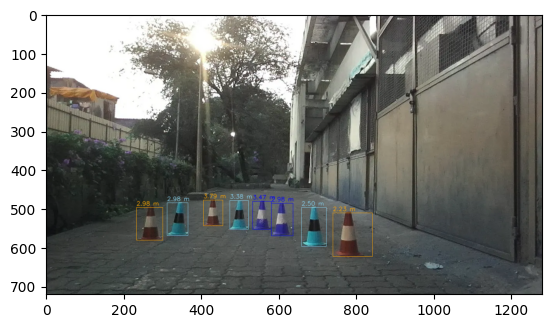

In [9]:
for i in range(len(data.boxes.cls)):
    crd = data.boxes.xywhn[i]
    color = data.boxes.cls[i]
    x = crd[0]
    y = crd[1]
    w = crd[2]
    h = crd[3]

    nx = int(float(x)*dw)
    ny = int(float(y)*dh)
    nw = int(float(w)*dw/2)
    nh = int(float(h)*dh/2) 

    cv2.rectangle(img, (nx-nw,ny-nh), (nx+nw,ny+nh), colors.get(int(color)), 1)
    depth = 500*0.25/nh

    label = f"{depth:.2f} m"
    cv2.putText(img,label,(nx - nw, ny - nh - 5),cv2.FONT_HERSHEY_SIMPLEX,0.5,colors.get(int(color)),1,cv2.LINE_AA)


plt.imshow(img)